hi


In [3]:
# [1] Install necessary libraries
!pip install scikeras

In [4]:
# [2] Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from keras.models import Sequential
from keras.layers import Dense, Dropout
from scikeras.wrappers import KerasRegressor

import pickle

In [5]:
# [3] Generate synthetic data
np.random.seed(10)
data_size = 1000
ages = np.random.randint(18, 65, data_size)
sex = np.random.choice(['male', 'female'], data_size)
bmi = np.random.uniform(18, 35, data_size)
children = np.random.randint(0, 5, data_size)
smoker = np.random.choice(['yes', 'no'], data_size)
region = np.random.choice(['northeast', 'northwest', 'southeast', 'southwest'], data_size)


In [6]:
# [4] Calculate charges
charges = 200 * ages + 100 * (bmi - 25) + 500 * (smoker == 'yes') + 1000 * children + np.random.normal(0, 1000, data_size)
charges = np.maximum(0, charges)


In [7]:
# [5] Create DataFrame
data = pd.DataFrame({
    'age': ages,
    'sex': sex,
    'bmi': bmi,
    'children': children,
    'smoker': smoker,
    'region': region,
    'charges': charges
})


In [8]:
# [6] Print sample data
print(data.head(10))



   age     sex        bmi  children smoker     region       charges
0   27    male  25.952100         4     no  southwest  10395.327333
1   54    male  34.551742         3     no  northeast  16517.699130
2   33    male  20.740403         1     no  southeast   6153.621956
3   18    male  26.360395         4     no  northwest   7718.378094
4   46    male  24.481995         2     no  northeast   9888.779639
5   43  female  33.097111         3     no  southeast  11825.342049
6   47    male  33.657550         3    yes  southeast  13815.558627
7   47    male  22.553527         2     no  northwest  10041.072856
8   26  female  27.081973         2     no  northwest   5916.663762
9   27    male  23.610199         0     no  northeast   6327.429280


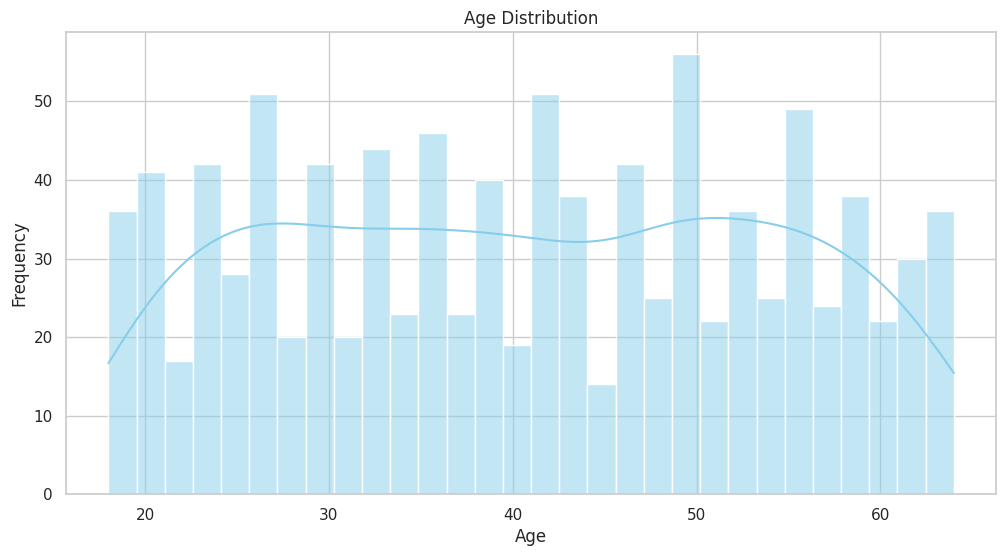

/tmp/ipykernel_7193/1883238420.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoker', y='bmi', data=data, palette='Set2')


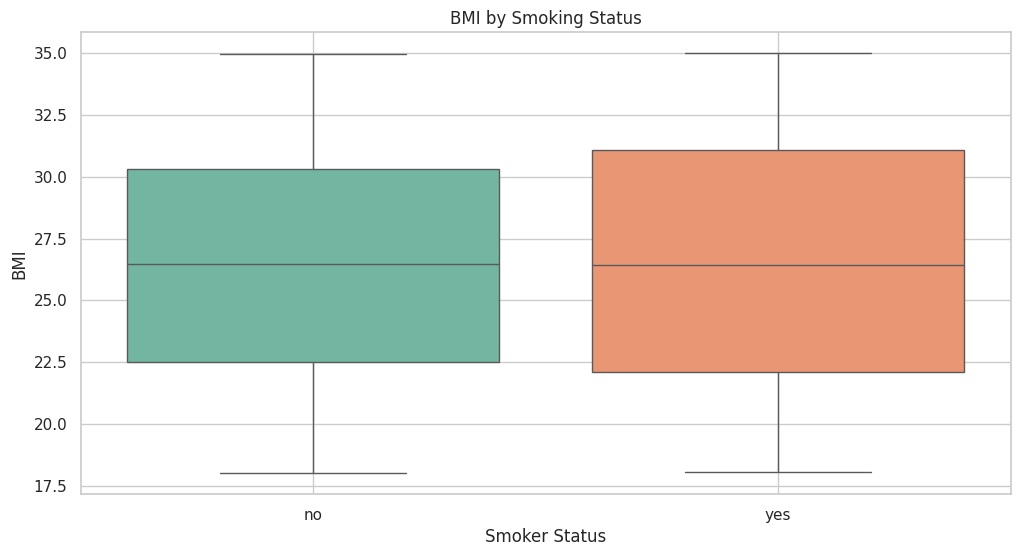

/tmp/ipykernel_7193/1883238420.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sex', data=data, palette='Set2')


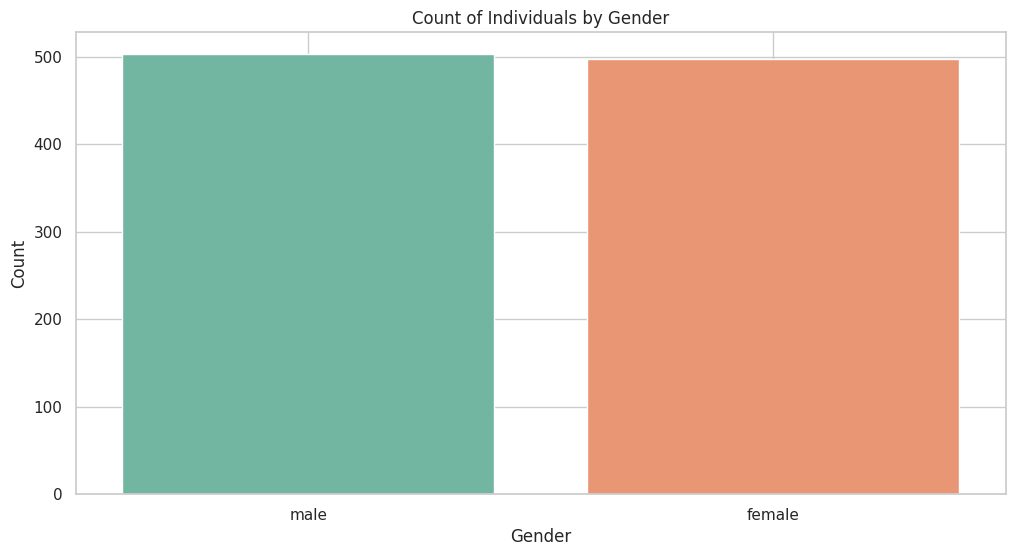

/tmp/ipykernel_7193/1883238420.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='region', y='charges', data=data, estimator=np.mean, palette='Set2')


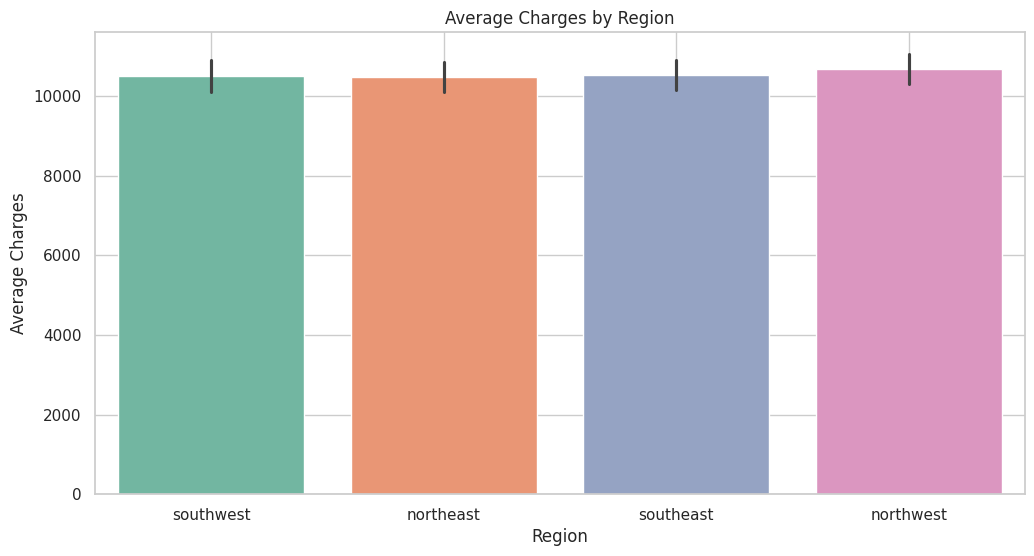

In [9]:
# [7] Data Visualizations
sns.set(style="whitegrid")

plt.figure(figsize=(12, 6))
sns.histplot(data['age'], bins=30, kde=True, color='skyblue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x='smoker', y='bmi', data=data, palette='Set2')
plt.title('BMI by Smoking Status')
plt.xlabel('Smoker Status')
plt.ylabel('BMI')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
sns.countplot(x='sex', data=data, palette='Set2')
plt.title('Count of Individuals by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x='region', y='charges', data=data, estimator=np.mean, palette='Set2')
plt.title('Average Charges by Region')
plt.xlabel('Region')
plt.ylabel('Average Charges')
plt.grid(True)
plt.show()


In [10]:
# [8] Encode categorical variables
label_encoders = {}
for column in ['sex', 'smoker', 'region']:
    le = LabelEncoder()
    data[column] = le.fit_transform(data[column])
    label_encoders[column] = le


In [11]:
# [9] Add BMI categories
data['bmi_category'] = pd.cut(data['bmi'], bins=[0, 18.5, 24.9, 29.9, 35, np.inf],
                              labels=['Underweight', 'Normal', 'Overweight', 'Obese', 'Severely Obese'])


In [12]:
# [10] One-hot encode BMI category
data = pd.get_dummies(data, columns=['bmi_category'], drop_first=True)

In [13]:
# [11] Define features and target
X = data.drop('charges', axis=1)
y = data['charges']

In [14]:
# [12] Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
print("Shape of Full Data:", X.shape)
print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Shape of Full Data: (1000, 10)
Training Shape: (800, 10)
Testing Shape: (200, 10)


In [15]:
# [13] Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
# [14] Define model builder function
def create_model(optimizer='adam'):
    model = Sequential()
    model.add(Dense(128, input_dim=X_train.shape[1], activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='linear'))
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    return model

In [17]:

# [15] Use KerasRegressor
model = KerasRegressor(model=create_model, optimizer='adam', epochs=100, batch_size=32, verbose=0)


In [18]:
# [16] Hyperparameter tuning
param_grid = {'optimizer': ['adam', 'rmsprop']}
grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, n_jobs=-1)


In [19]:
# [17] Train the model
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

model = RandomForestRegressor()

# Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10]
}

grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=5)
grid_result = grid.fit(X_train, y_train)



In [20]:
# [18] Best hyperparameters
print(f"Best Hyperparameters: {grid_result.best_params_}")


Best Hyperparameters: {'max_depth': 10, 'n_estimators': 100}


In [21]:

# [19] Best model
best_model = grid_result.best_estimator_


In [22]:
# [20] Evaluate the model
loss = best_model.score(X_test, y_test)
print(f"Test Loss (MSE): {loss}")


Test Loss (MSE): 0.8679975431182828


In [23]:
# [21] Make predictions
predictions = best_model.predict(X_test)

In [24]:
# [22] Evaluate metrics
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R-squared (as percentage): {r2 * 100:.2f}%")

Mean Absolute Error: 951.689582206915
Mean Squared Error: 1406888.1653287483
Root Mean Squared Error: 1186.1231661715187
R-squared (as percentage): 86.80%


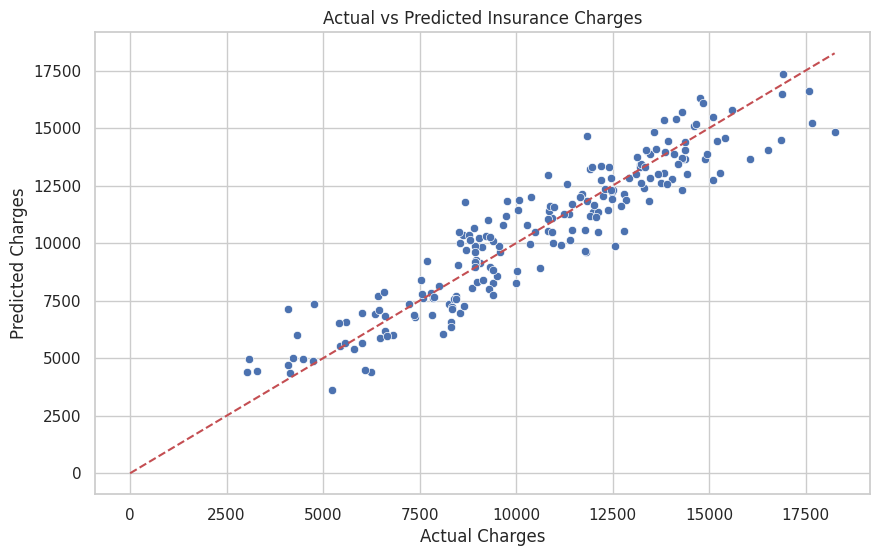

In [25]:
# [23] Actual vs Predicted plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=predictions)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Insurance Charges')
plt.plot([0, max(y_test)], [0, max(y_test)], 'r--')
plt.show()


In [26]:
# After fitting the best model:
best_model = grid_result.best_estimator_

In [27]:
import ipywidgets as widgets
from IPython.display import display

# Create input widgets for the features
age_widget = widgets.IntSlider(min=18, max=65, step=1, description='Age:')
sex_widget = widgets.Dropdown(options=[('Male', 1), ('Female', 0)], description='Sex:')
bmi_widget = widgets.FloatSlider(min=10, max=50, step=0.1, description='BMI:')
children_widget = widgets.IntSlider(min=0, max=5, step=1, description='Children:')
smoker_widget = widgets.Dropdown(options=[('Yes', 1), ('No', 0)], description='Smoker:')
region_widget = widgets.Dropdown(options=[
    ('Northeast', 0),
    ('Northwest', 1),
    ('Southeast', 2),
    ('Southwest', 3)
], description='Region:')

# BMI category will be auto calculated inside prediction function

predict_button = widgets.Button(description="Predict Charge")
output = widgets.Output()

def on_predict_clicked(b):
    output.clear_output()
    age = age_widget.value
    sex = sex_widget.value
    bmi = bmi_widget.value
    children = children_widget.value
    smoker = smoker_widget.value
    region = region_widget.value

    bmi_cat_cols = {
        'bmi_category_Normal': 0,
        'bmi_category_Overweight': 0,
        'bmi_category_Obese': 0,
        'bmi_category_Severely Obese': 0
    }

    if bmi < 18.5:
        pass  # Underweight - no dummy columns (all zeros)
    elif bmi < 25:
        bmi_cat_cols['bmi_category_Normal'] = 1
    elif bmi < 30:
        bmi_cat_cols['bmi_category_Overweight'] = 1
    elif bmi < 35:
        bmi_cat_cols['bmi_category_Obese'] = 1
    else:
        bmi_cat_cols['bmi_category_Severely Obese'] = 1

    input_dict = {
        'age': age,
        'sex': sex,
        'bmi': bmi,                # Include bmi numeric here!
        'children': children,
        'smoker': smoker,
        'region': region,
        **bmi_cat_cols
    }

    input_df = pd.DataFrame([input_dict])
    input_scaled = scaler.transform(input_df)
    pred_charge = best_model.predict(input_scaled)[0]

    with output:
        print(f"Predicted Insurance Charge in $:{pred_charge:,.2f}")


predict_button.on_click(on_predict_clicked)

# Display all widgets and output
display(age_widget, sex_widget, bmi_widget, children_widget, smoker_widget, region_widget, predict_button, output)


IntSlider(value=18, description='Age:', max=65, min=18)

Dropdown(description='Sex:', options=(('Male', 1), ('Female', 0)), value=1)

FloatSlider(value=10.0, description='BMI:', max=50.0, min=10.0)

IntSlider(value=0, description='Children:', max=5)

Dropdown(description='Smoker:', options=(('Yes', 1), ('No', 0)), value=1)

Dropdown(description='Region:', options=(('Northeast', 0), ('Northwest', 1), ('Southeast', 2), ('Southwest', 3…

Button(description='Predict Charge', style=ButtonStyle())

Output()